# Module 6.2 — Visualisation Principles and Chart Choice
### Reference & live-demo notebook — AJEBO Finance MFB Home Loan Applications

**Publica Academy Data Analysis Programme · Module 6, Week 7 (Data Storytelling and Visualisation)**

This notebook is built around **Before-and-After Critique**: for every principle, you'll see a
bad chart first, diagnose what's wrong yourself, then see the rebuilt version and the general
rule it teaches. Every chart uses the same dataset you cleaned in Module 6.1.

**Learning outcomes:**
1. Choose the appropriate chart type for a stated analytical question.
2. Apply labelling and formatting standards that make a chart self-explanatory.
3. Identify misleading visualisation practices.

**Dataset:** `ajebo_finance_loan_applications_CLEANED.csv` — 356 rows, the actual output of the
Module 6.1 cleaning pipeline. No real personal data.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('ajebo_finance_loan_applications_CLEANED.csv', parse_dates=['Application_Date'])

# House style for GOOD charts throughout this notebook
GOOD = '#028090'      # primary teal
ACCENT = '#02C39A'    # mint accent, used to highlight ONE thing
MUTED = '#B7C4C4'     # muted grey-teal for non-highlighted bars
BAD_RAINBOW = ['#e6194B','#3cb44b','#ffe119','#4363d8','#f58231',
               '#911eb4','#46f0f0','#f032e6','#bcf60c','#fabebe']

plt.rcParams['font.size'] = 11
sns.set_style('white')

df.shape


(356, 18)

---
## 1. Why visualisation matters

**Before-and-after critique, round 1.** AJEBO's operations lead asks: *"which branch should we
be worried about?"* Here is the answer, delivered as a table.

In [2]:
summary = df.groupby('Branch_Region').agg(
    Applications=('Application_ID', 'count'),
    Avg_Income_NGN=('Monthly_Income_NGN', 'mean'),
    Avg_Loan_NGN=('Loan_Amount_NGN', 'mean'),
    Approval_Rate=('Loan_Status', lambda s: (s == 'Approved').mean()),
).round(0)
summary


,Applications,Avg_Income_NGN,Avg_Loan_NGN,Approval_Rate
Branch_Region,,,,
Abuja,62,239247.0,3248274.0,1.0
Ibadan,41,216307.0,2871488.0,1.0
Kano,32,274109.0,4262125.0,0.0
Lagos,109,238412.0,3591156.0,1.0
Port Harcourt,45,231916.0,3175467.0,1.0
Rural North,67,252442.0,3267299.0,1.0


**Diagnose it yourself first:** how many seconds did it take you to find the branch with the
lowest approval rate? Now look at the chart below, answering the exact same question.

**The principle:** a table makes the reader do the comparison in their head, row by row. A chart
does the comparison *for* the reader — the eye finds the shortest bar in under a second. Neither
format is wrong; they solve different problems (more on that in Section 12 — Table vs Chart).
The mistake is defaulting to a table (or a chart) out of habit rather than choosing based on the
question.

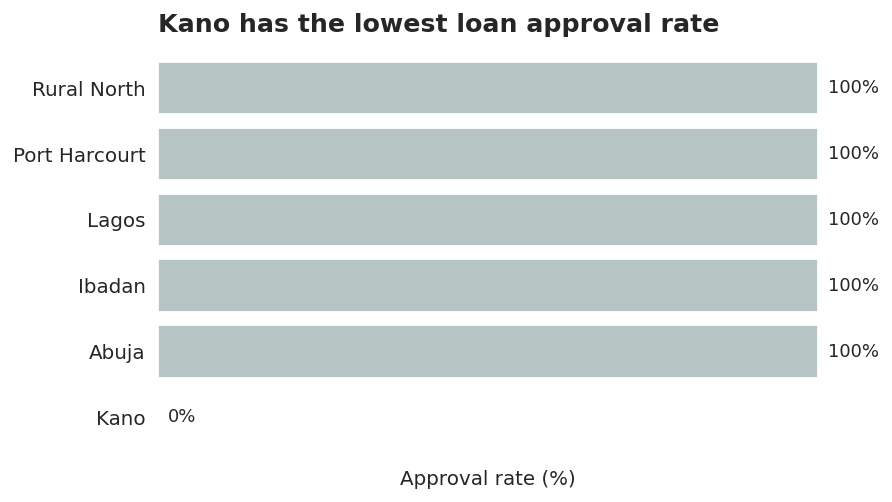

In [3]:
order = summary['Approval_Rate'].sort_values().index
colors = [ACCENT if r == order[0] else MUTED for r in order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(order, summary.loc[order, 'Approval_Rate'] * 100, color=colors)
ax.set_xlim(0, 100)
ax.set_xlabel('Approval rate (%)')
ax.set_title('Kano has the lowest loan approval rate', fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('')
for bar, val in zip(bars, summary.loc[order, 'Approval_Rate'] * 100):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=10)
sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.tight_layout()
plt.show()


**The rule:** *pick the format that lets the reader answer the actual question in the fewest
seconds, not the format that's fastest for you to produce.*

---
## 2. What makes a chart effective

An effective chart has three properties, in this order of importance:

1. **Accurate** — it does not distort or mislead, even by accident (Section 13 covers this in
   depth).
2. **Clear** — a reader unfamiliar with the data understands the finding without narration.
3. **Efficient** — it says only what's needed. Every extra gridline, colour, or decoration is a
   small tax on the reader's attention.

Notice what's *not* on this list: impressive, colourful, or "on-brand." Those are welcome
side-effects of a good chart, never the goal of one.

---
## 3. Start with the analytical question

The single most common mistake in this module is opening a plotting library before deciding what
question the chart must answer. The question determines everything downstream: which columns
you need, what kind of comparison you're making, and therefore which chart type is even a
candidate.

**Bad habit:** "let me chart Monthly_Income_NGN" (a column, not a question).
**Good habit:** "which region has applicants with lower purchasing power, and does that explain
their approval rate?" (a question, which then tells you: compare income across regions — a
grouped comparison, candidate charts are a bar chart of group means or a boxplot of the full
distribution per group).

---
## 4. Choosing charts based on the question — the framework

Use this four-step framework on every business question before opening a notebook or Excel:

```
QUESTION  ->  DATA TYPE  ->  COMPARISON  ->  APPROPRIATE CHART
```

| Step | Ask yourself | Example (AJEBO) |
|---|---|---|
| **Question** | What decision does this chart inform? | "Should we change Kano's lending criteria?" |
| **Data type** | Categorical, numeric, time series, geographic? | Branch_Region (categorical) × Approval rate (numeric) |
| **Comparison** | Comparison, trend, distribution, relationship, composition, or ranking? | Comparison across a small number of categories |
| **Chart** | The narrowest chart type that fits everything above | Sorted horizontal bar chart |

Work through the table left to right, every time — never chart-first.

---
## 5. Comparison

**Question:** *does average loan amount differ between Salaried and Self-Employed applicants?*

**Before-and-after critique.** Here is a first attempt.

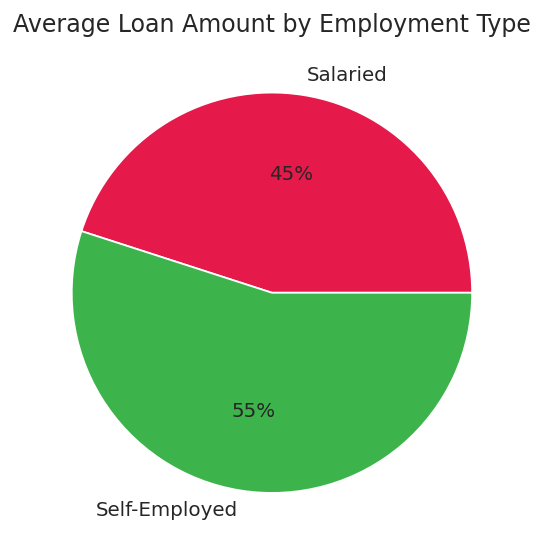

In [4]:
avg_loan = (df[df['Employment_Type'].isin(['Salaried', 'Self-Employed'])]
              .groupby('Employment_Type')['Loan_Amount_NGN'].mean())

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(avg_loan, labels=avg_loan.index, autopct='%1.0f%%', colors=BAD_RAINBOW[:2])
ax.set_title('Average Loan Amount by Employment Type')
plt.show()


**Diagnose it yourself:** what does this pie chart actually tell you? Look closely — the two
percentages you see (e.g. "48% / 52%") are NOT the two average loan amounts. They're each
average's *share of the sum of both averages*, a number with no business meaning at all.

**The principle:** a pie chart shows parts of a single whole (100% of something). Two independent
averages are not parts of a whole — there is no "whole" being divided between Salaried and
Self-Employed applicants. Using a pie here doesn't just look worse than a bar chart, it
**reports the wrong number**.

**Rebuild:**

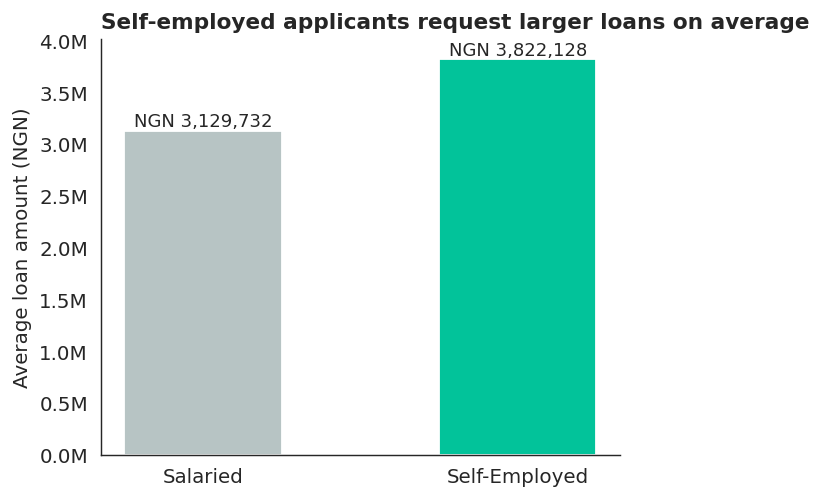

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = [ACCENT if v == avg_loan.max() else MUTED for v in avg_loan]
bars = ax.bar(avg_loan.index, avg_loan, color=colors, width=0.5)
ax.set_title('Self-employed applicants request larger loans on average', fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('Average loan amount (NGN)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, avg_loan):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'NGN {val:,.0f}', ha='center', va='bottom', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


**The rule:** *a pie chart answers "what share of the whole is this category?" — nothing else.
If your question is "how do these two numbers compare?", reach for a bar chart, every time.*

---
## 6. Trends over time

**Question:** *how has application volume changed over the period covered by our data?*

**Before-and-after critique.**

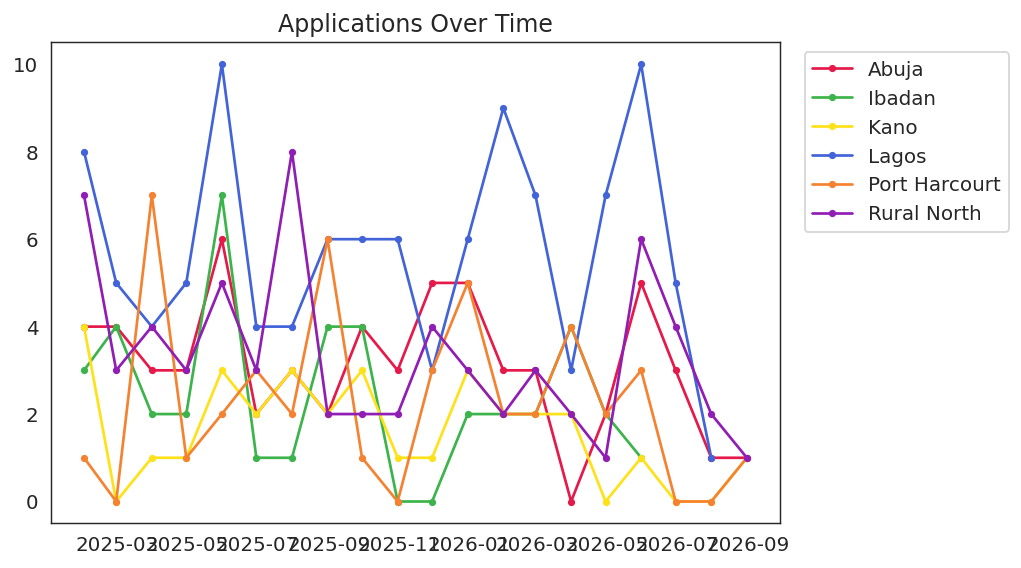

In [6]:
monthly_by_region = (df.set_index('Application_Date')
                        .groupby('Branch_Region')
                        .resample('ME').size()
                        .unstack(0))

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, col in enumerate(monthly_by_region.columns):
    ax.plot(monthly_by_region.index, monthly_by_region[col], color=BAD_RAINBOW[i], marker='o', markersize=3)
ax.legend(monthly_by_region.columns, loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_title('Applications Over Time')
plt.tight_layout()
plt.show()


**Diagnose it yourself:** six overlapping, similarly-coloured lines, a legend competing for
space outside the plot, and monthly counts so small (some branches have 1-3 applications in a
given month) that every line is mostly noise. What is the one thing this chart wants you to walk
away knowing? There isn't one.

**The principle:** a line chart earns its place when the *shape* of change over time is the
finding. Six noisy, similar-looking lines don't have six findings — they have zero, because no
single shape stands out. Match the number of series to the number of things you actually want
the reader to compare (rarely more than 2-3 on one chart).

**Rebuild — the trend that actually matters:**

Before charting the total, notice the data's most recent month is **partial** (it ends
2026-08-06, six days into August) — including it would show a misleading final-month "crash"
that's really just an incomplete bucket. Excluding a partial current period is a legitimate,
necessary cleaning decision for any time-series chart, not cherry-picking (Section 13 covers the
dishonest version of trimming a time period).

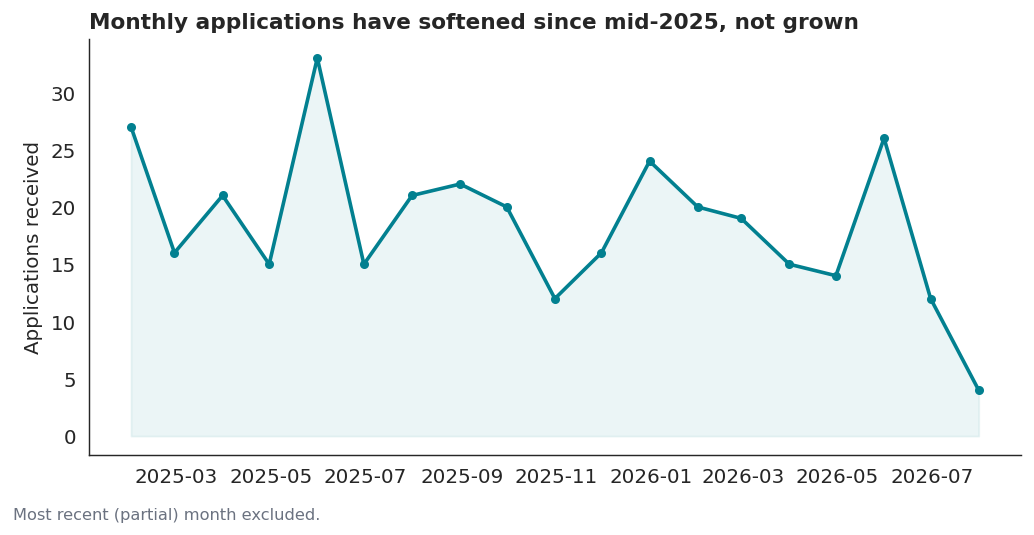

In [7]:
monthly_total = df.set_index('Application_Date').resample('ME').size()
monthly_total = monthly_total.iloc[:-1]  # drop the partial final month (only 6 days of data)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly_total.index, monthly_total.values, color=GOOD, linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_total.index, monthly_total.values, color=GOOD, alpha=0.08)
ax.set_title('Monthly applications have softened since mid-2025, not grown',
             fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('Applications received')
ax.set_xlabel('')
fig.text(0.01, -0.02, 'Most recent (partial) month excluded.', fontsize=9, color='#6B7280')
sns.despine()
plt.tight_layout()
plt.show()


**The rule:** *one clear line beats six blurry ones. If you need to show branch-level detail,
use small multiples (one mini-chart per branch, same scale) instead of cramming them into a
single noisy plot.*

---
## 7. Distribution

**Question:** *what does the shape of applicant income look like — is it skewed, are there
extreme values?*

**Before-and-after critique.**

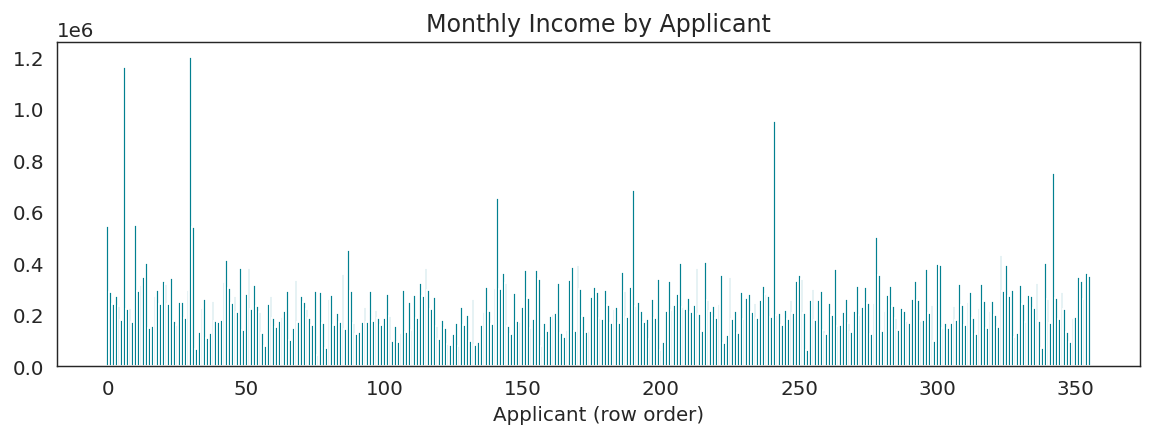

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(df)), df['Monthly_Income_NGN'].values, color=GOOD, width=1.0)
ax.set_title('Monthly Income by Applicant')
ax.set_xlabel('Applicant (row order)')
plt.tight_layout()
plt.show()


**Diagnose it yourself:** the x-axis is "row order in the file" — a meaningless category with
356 near-invisible bars. This chart cannot answer "is the distribution skewed?" at all; it can
only show that a couple of applicants earn a lot more than everyone else, which you'd have found
faster with `.describe()`.

**The principle:** distribution questions are about *how values are spread*, not about
individual applicants in file order. A bar chart compares named categories; it is the wrong tool
the moment your x-axis stops being a meaningful category and becomes "row number."

**Rebuild — a histogram, the correct tool for shape:**

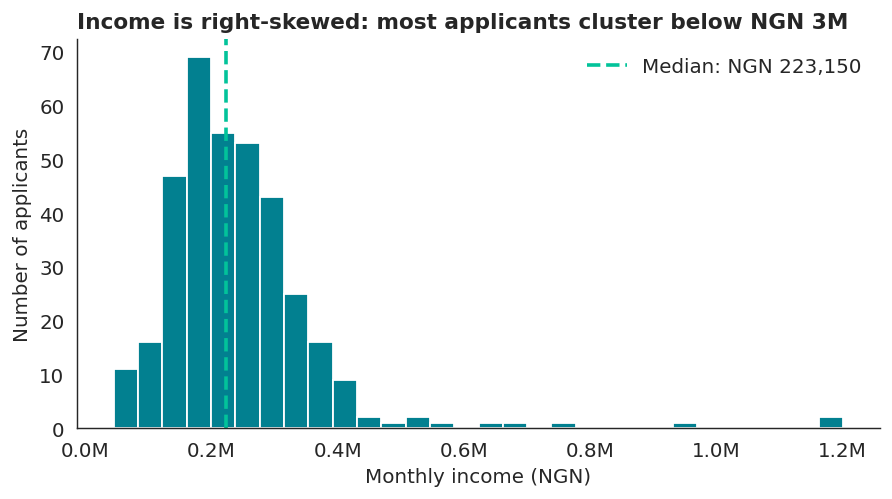

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['Monthly_Income_NGN'], bins=30, color=GOOD, edgecolor='white')
ax.axvline(df['Monthly_Income_NGN'].median(), color=ACCENT, linestyle='--', linewidth=2,
           label=f"Median: NGN {df['Monthly_Income_NGN'].median():,.0f}")
ax.set_title('Income is right-skewed: most applicants cluster below NGN 3M', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('Monthly income (NGN)')
ax.set_ylabel('Number of applicants')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


**A second good option — when you need to compare the shape across groups:**

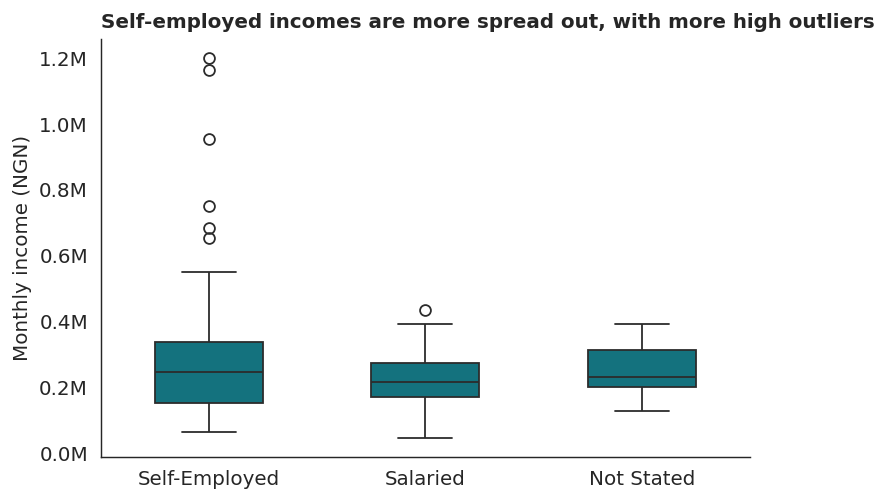

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Employment_Type', y='Monthly_Income_NGN', color=GOOD, ax=ax, width=0.5)
ax.set_title('Self-employed incomes are more spread out, with more high outliers', fontsize=11, fontweight='bold', loc='left')
ax.set_ylabel('Monthly income (NGN)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
sns.despine()
plt.tight_layout()
plt.show()


**The rule:** *if the question contains the words "spread," "typical," "skewed," or
"outliers," reach for a histogram (one group) or a box plot (comparing groups) — never a bar
chart of individual records.*

---
## 8. Relationship / correlation

**Question:** *does requesting a larger loan track with having a higher income?*

**Before-and-after critique.**

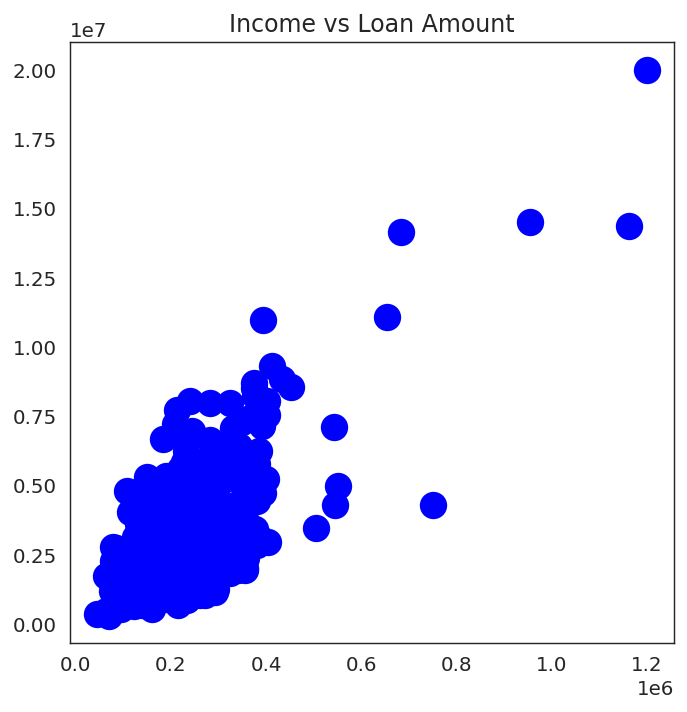

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['Monthly_Income_NGN'], df['Loan_Amount_NGN'], s=200, color='blue')
ax.set_title('Income vs Loan Amount')
plt.show()


**Diagnose it yourself:** the markers are so large and so opaque that dense regions merge into
a solid blob — you can no longer tell if there are 5 applicants or 50 stacked in the lower-left.
No axis units, no indication of what a "high" or "low" value even means in Naira.

**The principle:** scatter plots live or die on point size and transparency. Oversized, fully
opaque markers hide exactly the density pattern a scatter plot exists to reveal.

**Rebuild:**

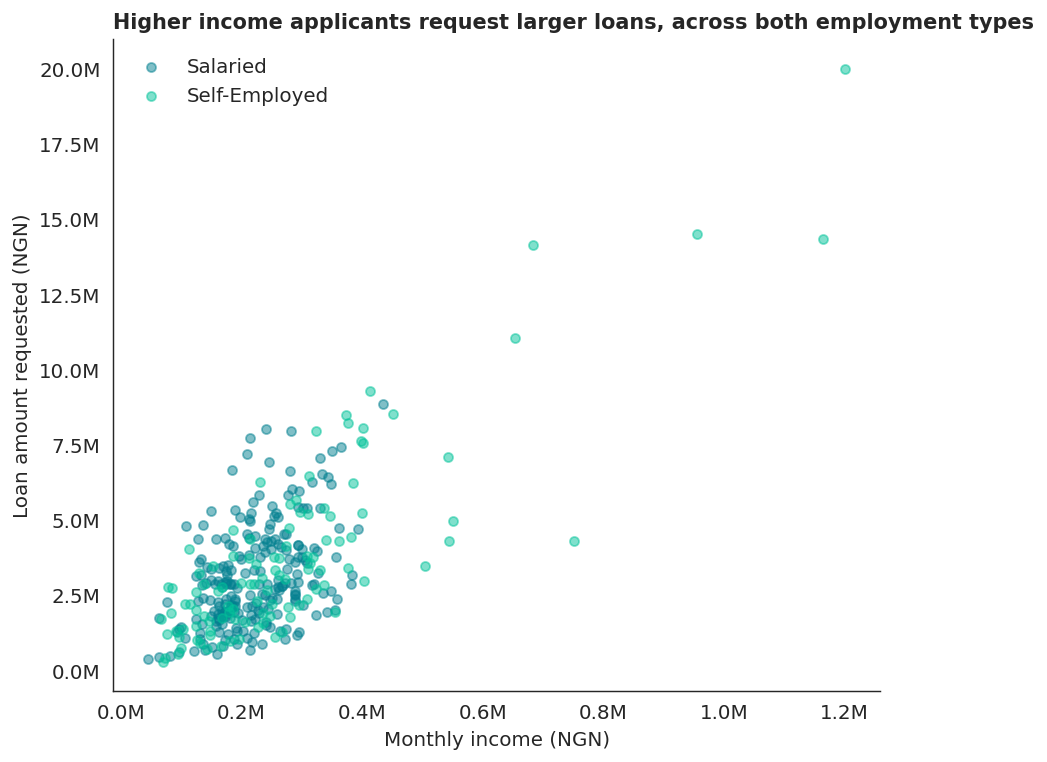

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
for etype, color in zip(['Salaried', 'Self-Employed'], [GOOD, ACCENT]):
    sub = df[df['Employment_Type'] == etype]
    ax.scatter(sub['Monthly_Income_NGN'], sub['Loan_Amount_NGN'], s=25, alpha=0.5, color=color, label=etype)

ax.set_title('Higher income applicants request larger loans, across both employment types',
             fontsize=11.5, fontweight='bold', loc='left')
ax.set_xlabel('Monthly income (NGN)')
ax.set_ylabel('Loan amount requested (NGN)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(frameon=False, title=None)
sns.despine()
plt.tight_layout()
plt.show()


**The rule:** *use `alpha` (transparency) and a sensible marker size on every scatter plot with
more than ~30 points — density is often the actual finding, and oversized opaque points destroy
it. Always label both axes with their units.*

---
## 9. Composition

**Question:** *what share of approved loans is for each stated purpose?*

**Before-and-after critique.**

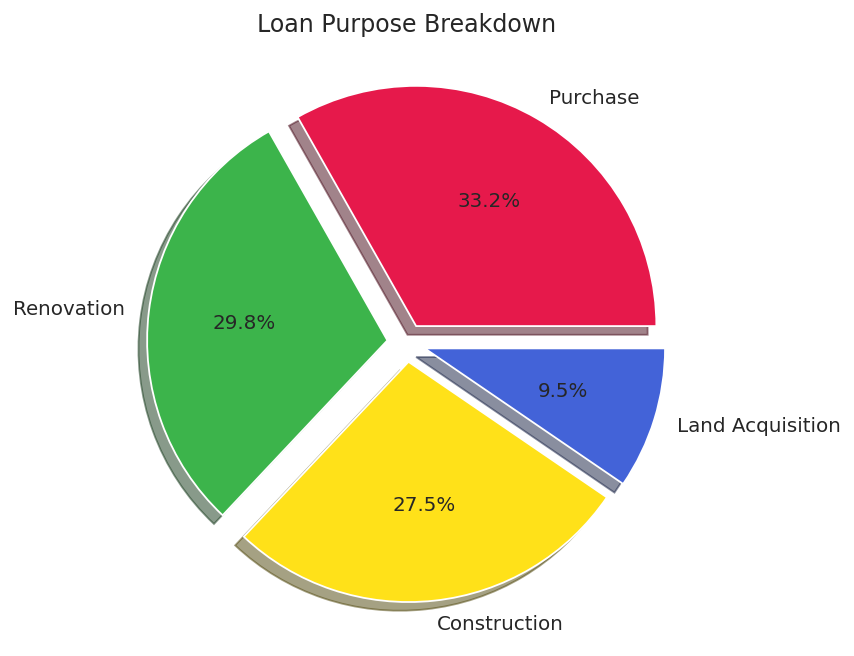

In [13]:
approved = df[df['Loan_Status'] == 'Approved']
purpose_counts = approved['Loan_Purpose'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(purpose_counts, labels=purpose_counts.index, colors=BAD_RAINBOW[:4],
       explode=[0.08]*4, shadow=True, autopct='%1.1f%%')
ax.set_title('Loan Purpose Breakdown')
plt.show()


**Diagnose it yourself:** the exploded slices and drop-shadow don't add information — they
add visual weight that makes the two closest slices even harder to compare by eye, since area and
angle judgements are already the weakest thing human vision does well.

**The principle:** pie charts are legitimate for composition — but only when there are few
categories (2-4), the differences are large enough to read, and decoration is kept to zero.
Here, a sorted bar communicates the same shares faster and more accurately.

**Rebuild:**

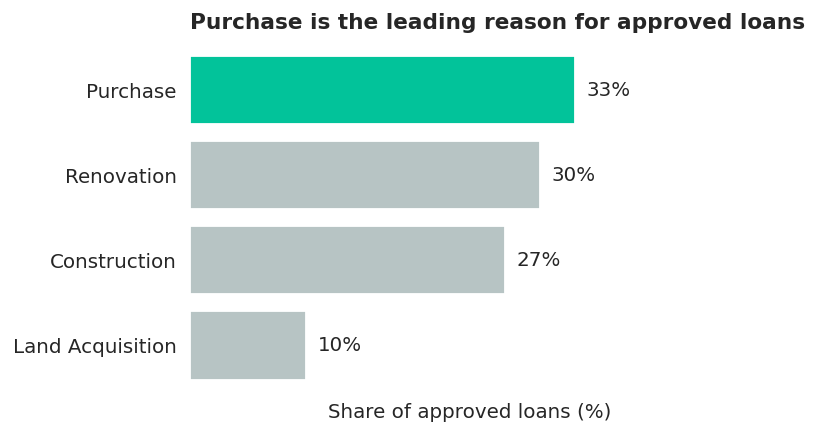

In [14]:
order = purpose_counts.sort_values(ascending=True)
pct = (order / order.sum() * 100).round(0)

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = [ACCENT if p == order.index[-1] else MUTED for p in order.index]
bars = ax.barh(order.index, pct, color=colors)
ax.set_title('Purchase is the leading reason for approved loans', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('Share of approved loans (%)')
ax.set_xlim(0, max(pct) + 15)
for bar, val in zip(bars, pct):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center')
sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.tight_layout()
plt.show()


**The rule:** *composition can be a pie chart only with few categories, big enough gaps
between them, and zero decoration. When in doubt, a sorted bar chart is a safer default and
scales to more categories without becoming unreadable.*

---
## 10. Ranking

**Question:** *rank the branches by number of applications processed.*

**Before-and-after critique.**

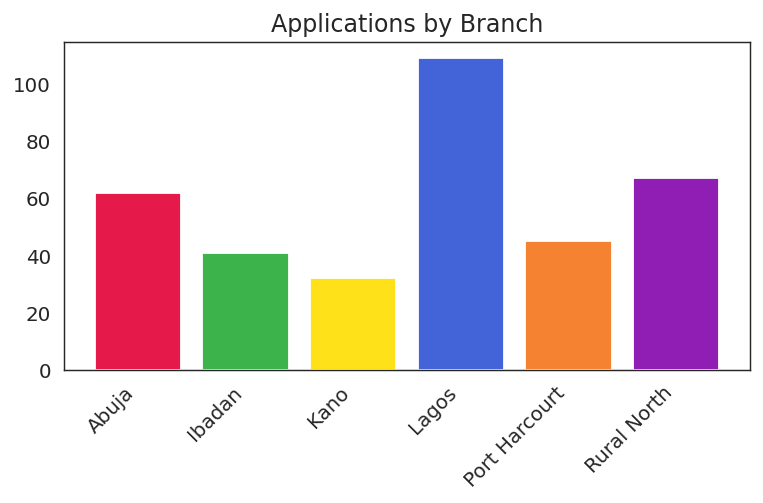

In [15]:
counts = df['Branch_Region'].value_counts()
# Deliberately NOT sorted by value - alphabetical, as many first drafts are
counts_alpha = counts.sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts_alpha.index, counts_alpha.values, color=BAD_RAINBOW[:6])
ax.set_title('Applications by Branch')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Diagnose it yourself:** alphabetical order buries the ranking the question actually asked
for — you still have to scan every bar to find the biggest and smallest. Rotated labels and a
different colour per bar add friction without adding meaning (colour here doesn't encode
anything).

**The principle:** for a ranking question, order *is* the answer. Sorting the bars by value does
the reader's work for them; a shared colour keeps attention on the ranking, not on decoration.

**Rebuild:**

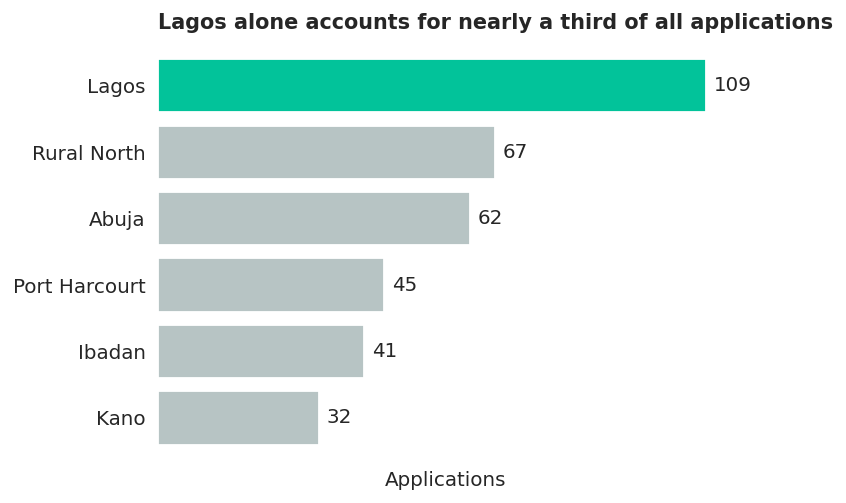

In [16]:
counts_sorted = counts.sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
colors = [ACCENT if c == counts_sorted.max() else MUTED for c in counts_sorted]
bars = ax.barh(counts_sorted.index, counts_sorted.values, color=colors)
ax.set_title('Lagos alone accounts for nearly a third of all applications',
             fontsize=11.5, fontweight='bold', loc='left')
ax.set_xlabel('Applications')
for bar, val in zip(bars, counts_sorted.values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, str(val), va='center')
sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.tight_layout()
plt.show()


**The rule:** *for any ranking question, sort the bars by value (usually descending, or
ascending for horizontal bars reading top-to-bottom), use one colour, and reserve a second colour
only to highlight the single most important bar.*

---
## 11. Geographic data — where appropriate

**Question:** *is application volume geographically concentrated?*

AJEBO's data only identifies six branch regions — not precise coordinates — so a real
choropleth map is not warranted here. This section is deliberately about **judgement**: knowing
when a map earns its place versus when it's just a decorative version of a bar chart you already
have (Section 10).

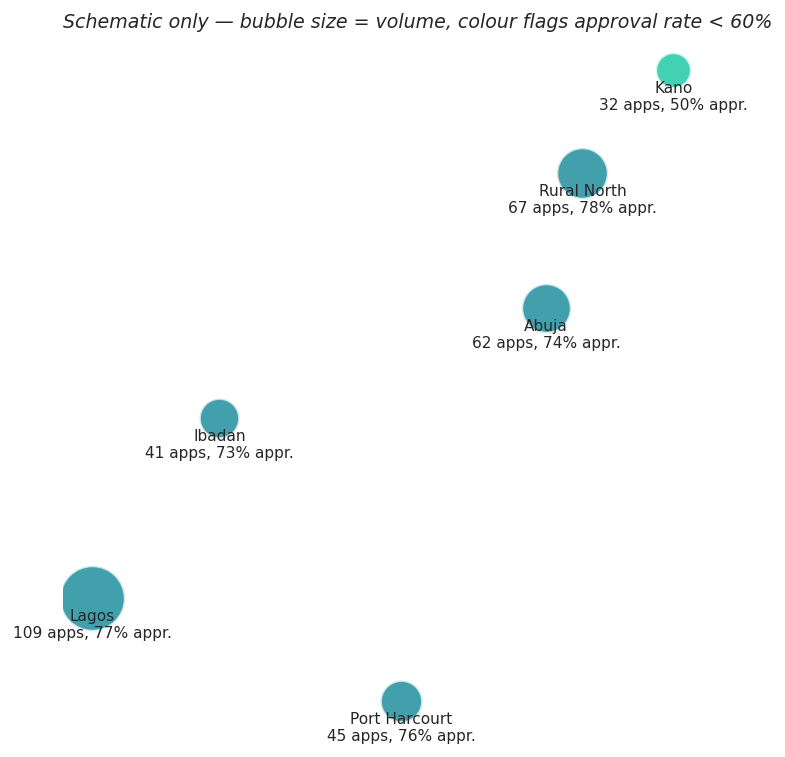

In [17]:
# Illustrative schematic only - approximate relative positions, NOT a real map projection.
region_positions = {
    'Lagos': (2.2, 4.8), 'Ibadan': (3.6, 7.6), 'Abuja': (7.2, 9.3),
    'Port Harcourt': (5.6, 3.2), 'Kano': (8.6, 13.0), 'Rural North': (7.6, 11.4),
}
vol = df['Branch_Region'].value_counts()
appr = df.groupby('Branch_Region')['Loan_Status'].apply(lambda s: (s == 'Approved').mean())

fig, ax = plt.subplots(figsize=(6, 6))
for region, (x, y) in region_positions.items():
    size = vol[region] * 12
    color = ACCENT if appr[region] < 0.6 else GOOD
    ax.scatter(x, y, s=size, color=color, alpha=0.75, edgecolor='white', linewidth=1.5)
    ax.annotate(f'{region}\n{vol[region]} apps, {appr[region]*100:.0f}% appr.',
                (x, y), textcoords='offset points', xytext=(0, -22), ha='center', fontsize=8.5)
ax.set_title('Schematic only — bubble size = volume, colour flags approval rate < 60%',
             fontsize=10.5, style='italic', loc='left')
ax.set_xticks([]); ax.set_yticks([])
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**The judgement call:** this bubble map does show that Kano (flagged) sits in the north,
geographically distinct from the cluster of stronger-performing branches. *If* a real spatial
pattern like "our weak branches cluster in one region" were the finding, a map would justify
itself. Here, with only six known points, the sorted bar chart from Section 1 answers "which
branch is the outlier" just as fast, with far less setup and no risk of a misleading projection.

**The rule:** *reach for a map only when relative geographic position is itself part of the
finding. If you're just ranking or comparing named locations, a sorted bar chart usually wins on
clarity and speed to build.*

---
## 12. When a table is better than a chart

**Question:** *the credit committee wants the exact applications count, average income, average
loan, and approval rate for all six branches, to quote in a memo.*

**Before-and-after critique.**

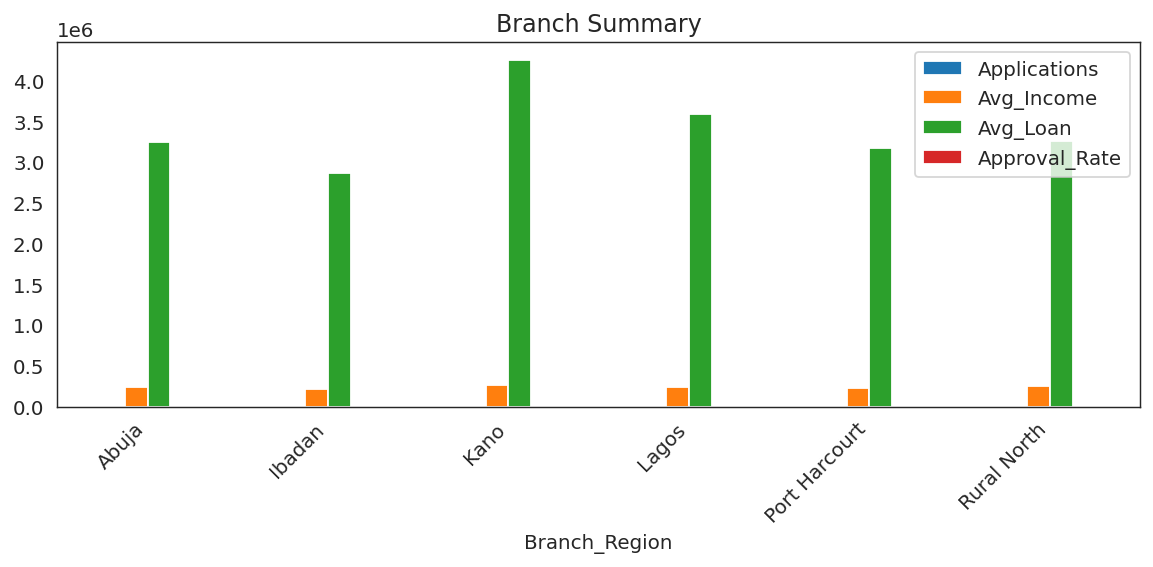

In [18]:
summary = df.groupby('Branch_Region').agg(
    Applications=('Application_ID', 'count'),
    Avg_Income=('Monthly_Income_NGN', 'mean'),
    Avg_Loan=('Loan_Amount_NGN', 'mean'),
    Approval_Rate=('Loan_Status', lambda s: (s == 'Approved').mean()),
)

fig, ax = plt.subplots(figsize=(9, 4.5))
summary.plot(kind='bar', ax=ax)
ax.set_title('Branch Summary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Diagnose it yourself:** Applications (tens) and Approval_Rate (a fraction near 1) are
invisible slivers next to Avg_Income and Avg_Loan (hundreds of thousands to millions). Worse,
the committee wanted **exact figures to quote**, and no chart lets you read off "3,248,274" with
any precision at all.

**The principle:** a chart's job is to show a *pattern* at a glance. When the actual requirement
is precise lookup of several unrelated-scale figures per category, for direct quoting or
copy-into-a-document use, a well-formatted table beats any chart — this is one of the few
"which chart" questions where the right answer is *no chart*.

**Rebuild — a table designed to be read, not just dumped:**

In [19]:
styled = (summary
    .rename(columns={'Avg_Income': 'Avg Income (NGN)', 'Avg_Loan': 'Avg Loan (NGN)',
                      'Approval_Rate': 'Approval Rate'})
    .sort_values('Approval Rate')
    .style
    .format({'Avg Income (NGN)': '{:,.0f}', 'Avg Loan (NGN)': '{:,.0f}', 'Approval Rate': '{:.0%}'})
    .background_gradient(subset=['Approval Rate'], cmap='RdYlGn', vmin=0.4, vmax=0.9)
    .set_caption('Branch summary — sorted by approval rate, exact figures for the credit committee memo'))
styled


,Applications,Avg Income (NGN),Avg Loan (NGN),Approval Rate
Branch_Region,,,,
Kano,32,"274,109","4,262,125",50%
Ibadan,41,"216,307","2,871,488",73%
Abuja,62,"239,247","3,248,274",74%
Port Harcourt,45,"231,916","3,175,467",76%
Lagos,109,"238,412","3,591,156",77%
Rural North,67,"252,442","3,267,299",78%


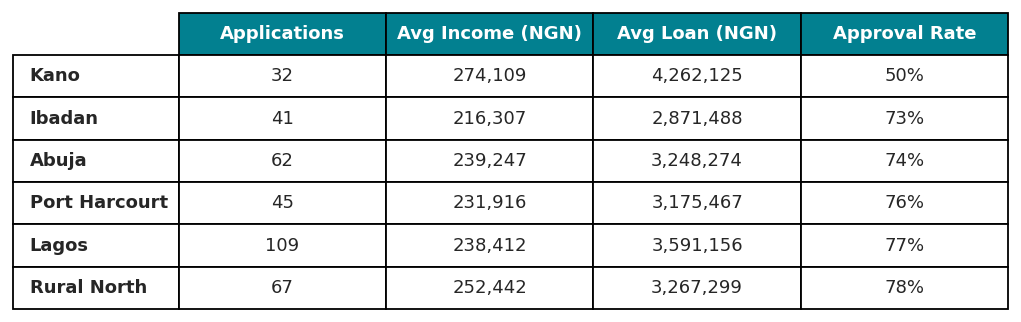

In [20]:
# Render the same table as an image too, for use outside the notebook (e.g. in slides)
tbl = summary.rename(columns={'Avg_Income': 'Avg Income (NGN)', 'Avg_Loan': 'Avg Loan (NGN)',
                               'Approval_Rate': 'Approval Rate'}).sort_values('Approval Rate')
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.axis('off')
table = ax.table(cellText=[[f"{v['Applications']:,.0f}", f"{v['Avg Income (NGN)']:,.0f}",
                             f"{v['Avg Loan (NGN)']:,.0f}", f"{v['Approval Rate']:.0%}"]
                            for _, v in tbl.iterrows()],
                  rowLabels=tbl.index, colLabels=tbl.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(GOOD); cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_text_props(fontweight='bold')
plt.tight_layout()
plt.show()


**The rule:** *if the request is "give me the exact numbers to quote or cross-check," build a
table. If the request is "help me see the pattern," build a chart. Sorting the table by the
column that matters most (here, approval rate) still gives you a ranking, even in table form.*

---
## Chart-type decision guide

A quick-reference card for the nine chart types covered in this module. Use it alongside the
framework from Section 4.

| Chart type | Best use | Poor use | Typical business question | Common mistake |
|---|---|---|---|---|
| **Bar chart** | Comparing a value across a handful of named categories | Showing a trend over many time points | "Which branch has the highest approval rate?" | Not sorting by value; starting the axis above zero |
| **Line chart** | Showing how one or two metrics change over a continuous sequence (usually time) | Comparing unrelated categories with no natural order | "How has monthly volume changed?" | Plotting too many series at once (Section 6) |
| **Histogram** | Showing the shape/spread of one numeric variable | Comparing named categories | "Is income skewed? Are there outliers?" | Too few or too many bins, hiding or fabricating structure |
| **Scatter plot** | Showing the relationship between two numeric variables | Fewer than ~15-20 points, or no real numeric relationship to explore | "Does income predict loan size?" | Oversized/opaque markers hiding density (Section 8) |
| **Box plot** | Comparing the distribution (median, spread, outliers) across groups | Audiences unfamiliar with quartiles, without a walkthrough | "How does income spread differ by employment type?" | Using it without explaining what the box and whiskers mean |
| **Stacked bar chart** | Showing composition *and* a total across categories at once | More than ~4-5 stacked segments (segments become unreadable) | "What's the approval mix within each branch?" | Too many segments; segments that are hard to compare once stacked |
| **Pie / donut chart** | Composition of a single whole, 2-4 categories, large gaps between shares | More than ~5 slices, or comparing two separate totals (Section 5) | "What share of approved loans is for Purchase?" | 3D effects, exploded slices, too many slices (Section 9) |
| **Heatmap** | Showing patterns across two categorical dimensions, or correlation across many variables at once | A small number of values better shown as a table or bar chart | "Which numeric fields move together?" | No colour scale legend; a colour scale that doesn't suit the data (e.g. rainbow for a single direction of magnitude) |
| **Table** | Precise lookup, quoting exact figures, many mixed-scale metrics per row | Spotting a pattern across many rows at a glance | "Give me the exact figures for the memo." | Dumping raw, unformatted numbers instead of designing for the reader (Section 12) |


**A heatmap example**, since it hasn't appeared yet — correlation across AJEBO's numeric fields:

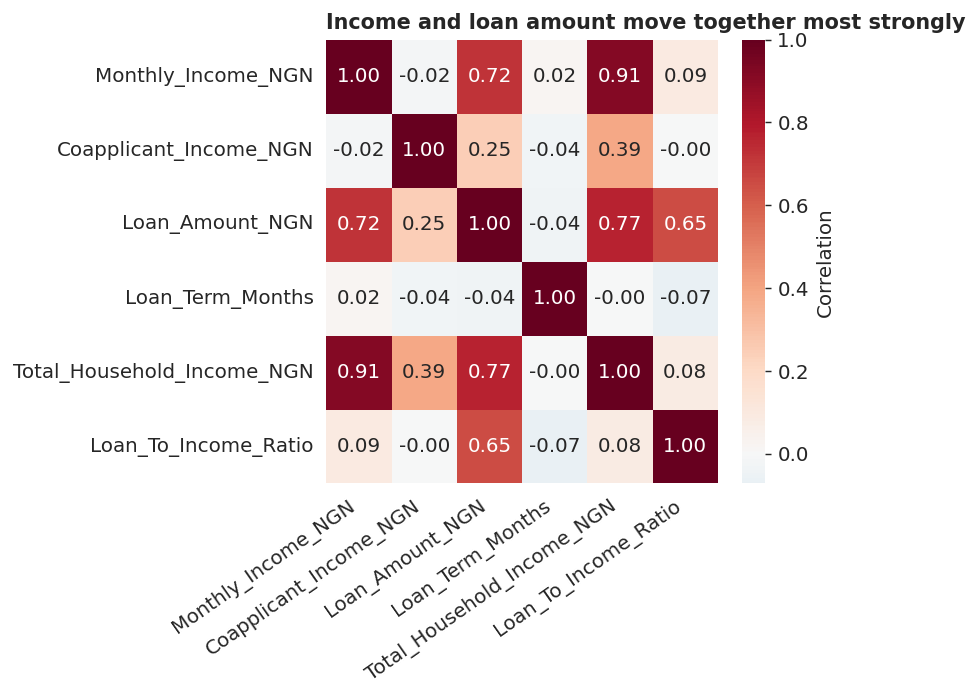

In [21]:
numeric_cols = ['Monthly_Income_NGN', 'Coapplicant_Income_NGN', 'Loan_Amount_NGN',
                'Loan_Term_Months', 'Total_Household_Income_NGN', 'Loan_To_Income_Ratio']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Income and loan amount move together most strongly',
             fontsize=11.5, fontweight='bold', loc='left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


---
## Visual design principles

Thirteen habits that separate a self-explanatory chart from one that needs a live narrator:

**Structure & text:** clear title (states the finding, not the column name) · informative
subtitle where useful · correct axis labels with units · appropriate scale (starts at zero unless
you have a specific, disclosed reason not to) · readable font sizes (nothing under ~10pt in a
projected slide).

**Data & categories:** meaningful categories (not "row order") · consistent formatting across
a related set of charts (same colours mean the same thing every time) · legends only when there's
more than one series, and placed so they don't compete with the data · data labels when the exact
value matters and there's room to show it without clutter.

**Restraint:** remove decoration that carries no information (drop shadows, 3D bevels, gridlines
that don't aid reading) · use whitespace deliberately — a less crowded chart is read faster ·
consider accessibility (colour-blind-safe palettes, and never rely on colour alone — pair it with
direct labels or position, as every "good" chart in this notebook already does).

**Before-and-after critique — every principle at once.**

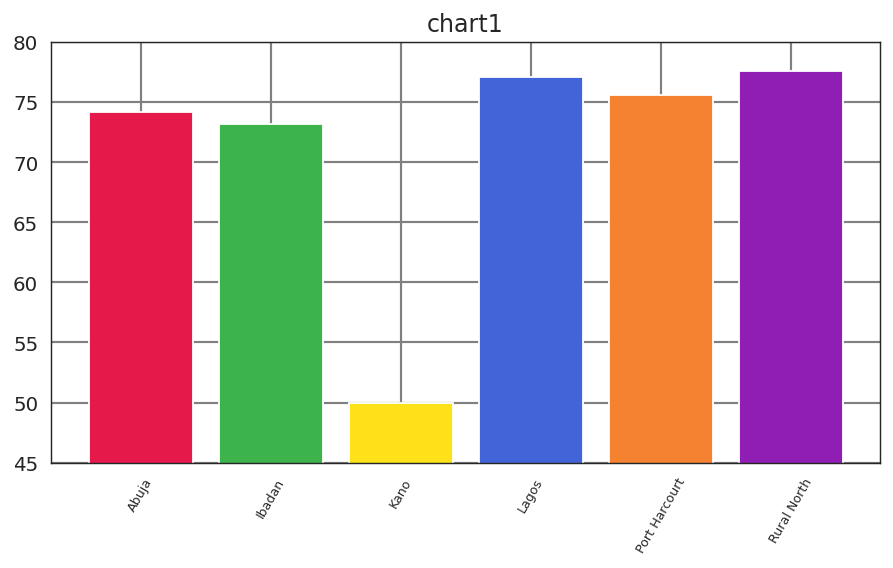

In [22]:
# A "kitchen sink" of violations in one chart
region_appr = df.groupby('Branch_Region')['Loan_Status'].apply(lambda s: (s == 'Approved').mean()) * 100
region_appr = region_appr.sort_index()  # not sorted by value

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(region_appr.index, region_appr.values, color=BAD_RAINBOW[:6])
ax.set_ylim(45, 80)          # truncated axis - exaggerates differences
ax.set_title('chart1')       # meaningless title
ax.grid(True, which='both', axis='both', color='gray', linewidth=1.2)  # heavy unnecessary gridlines
plt.xticks(rotation=60, fontsize=7)  # tiny, awkwardly rotated labels
plt.tight_layout()
plt.show()


**Diagnose it yourself** — list every violation before reading on: (1) title says nothing, (2)
y-axis starts at 45, not 0, making a 28-point spread look like a canyon, (3) heavy gridlines on
both axes compete with the bars, (4) six unrelated colours imply six different *kinds* of thing
when it's one variable across six categories, (5) tiny rotated labels are hard to read, (6) no
axis label at all telling you these are percentages.

**Rebuild, fixing every item above:**

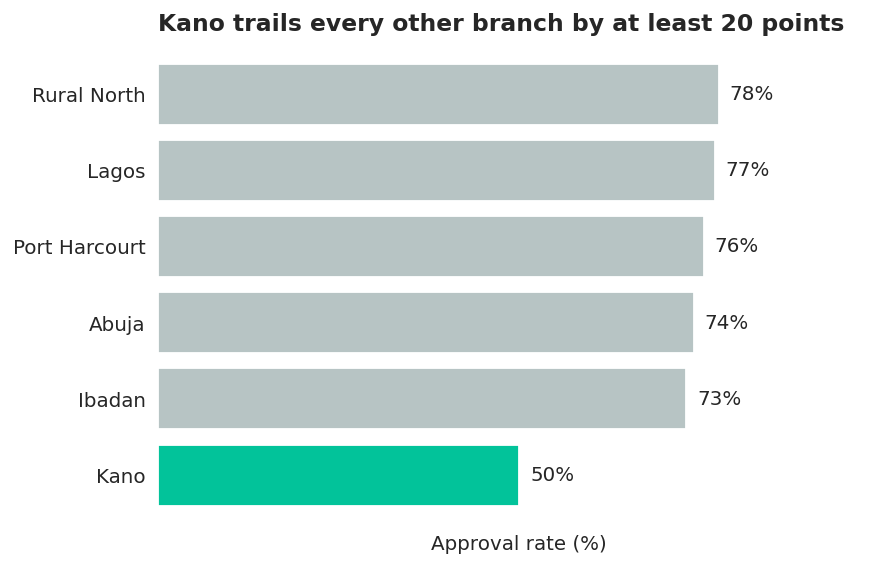

In [23]:
order = region_appr.sort_values().index
colors = [ACCENT if r == order[0] else MUTED for r in order]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(order, region_appr[order], color=colors)
ax.set_xlim(0, 100)
ax.set_xlabel('Approval rate (%)')
ax.set_title('Kano trails every other branch by at least 20 points',
             fontsize=13, fontweight='bold', loc='left')
for bar, val in zip(bars, region_appr[order]):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=11)
sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.tight_layout()
plt.show()


**The rule:** *run your own chart through this same list before sharing it. If you can't
answer "what should the reader notice first?" in one sentence, the title isn't done yet.*

---
## 13. Misleading visualisations

Every example below follows the same structure: **what is wrong → why it misleads → how to fix
it**. These are not exotic tricks — every one of them is a default setting or a single extra
argument away from the "good" charts you've already built in this notebook.

### 13.1 Truncated axes

**What is wrong:** the y-axis doesn't start at zero.
**Why it misleads:** it inflates small, possibly unimportant differences into what looks like a
dramatic gap.
**How to fix it:** start numeric axes at zero unless you have a specific, disclosed reason not
to (e.g. a stock price chart where zero is never in range).

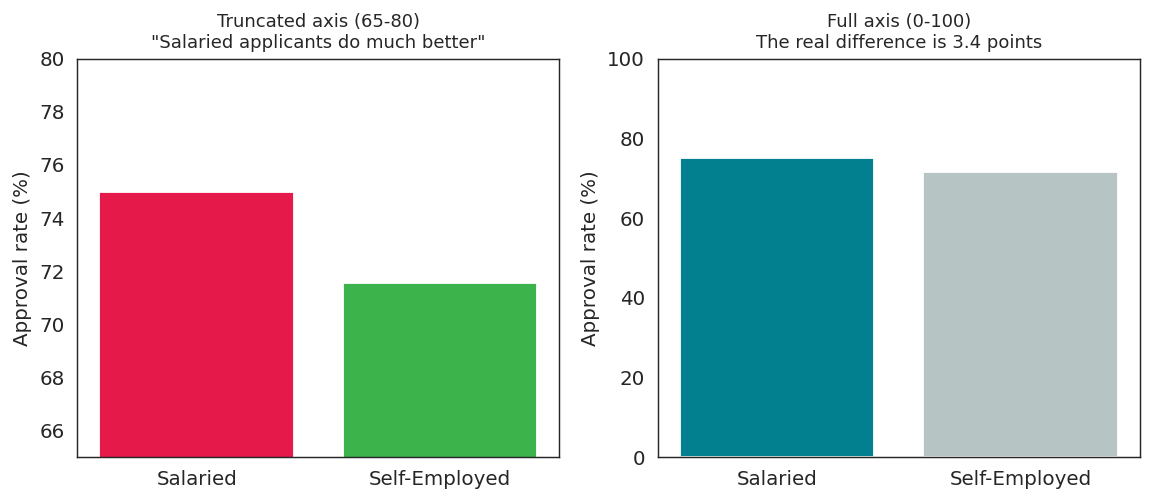

In [24]:
appr = df[df['Employment_Type'].isin(['Salaried', 'Self-Employed'])] \
         .groupby('Employment_Type')['Loan_Status'].apply(lambda s: (s == 'Approved').mean()) * 100

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(appr.index, appr.values, color=BAD_RAINBOW[:2])
axes[0].set_ylim(65, 80)
axes[0].set_title('Truncated axis (65-80)\n"Salaried applicants do much better"', fontsize=10)

axes[1].bar(appr.index, appr.values, color=[GOOD, MUTED])
axes[1].set_ylim(0, 100)
axes[1].set_title('Full axis (0-100)\nThe real difference is 3.4 points', fontsize=10)
for ax in axes:
    ax.set_ylabel('Approval rate (%)')
plt.tight_layout()
plt.show()


**The real gap is 3.4 percentage points** (75.0% vs 71.6%) — a difference the truncated
version on the left makes look roughly ten times more dramatic than it is.

### 13.2 3D charts

**What is wrong:** a third, purely decorative dimension is added to a 2D chart.
**Why it misleads:** perspective distorts apparent size — slices/bars angled toward the viewer
look larger than their true value, and it's genuinely harder to read exact values off a tilted
axis.
**How to fix it:** flatten it. A 3D pie or bar chart almost never encodes a real third variable
— it's decoration pretending to be data.

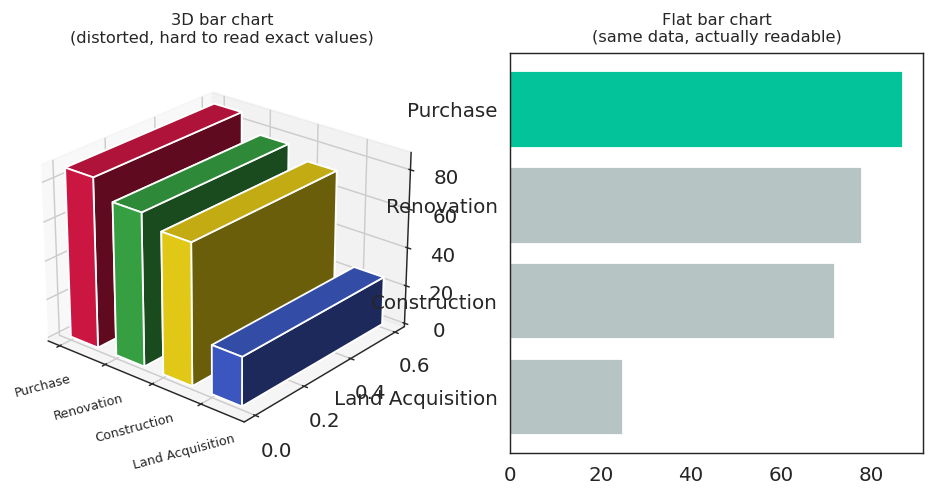

In [25]:
from mpl_toolkits.mplot3d import Axes3D

purpose_counts = df[df['Loan_Status'] == 'Approved']['Loan_Purpose'].value_counts()

fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121, projection='3d')
xs = range(len(purpose_counts))
ax1.bar3d(xs, [0]*len(xs), [0]*len(xs), 0.6, 0.6, purpose_counts.values, color=BAD_RAINBOW[:4])
ax1.set_title('3D bar chart\n(distorted, hard to read exact values)', fontsize=9)
ax1.set_xticks(xs); ax1.set_xticklabels(purpose_counts.index, rotation=15, fontsize=7)
ax1.view_init(elev=25, azim=-50)

ax2 = fig.add_subplot(122)
order = purpose_counts.sort_values()
ax2.barh(order.index, order.values, color=[ACCENT if v == order.max() else MUTED for v in order])
ax2.set_title('Flat bar chart\n(same data, actually readable)', fontsize=9)
plt.tight_layout()
plt.show()


### 13.3 Distorted proportions

**What is wrong:** circle *radius* (or icon height) is scaled linearly with the data value.
**Why it misleads:** area is what the eye perceives — scaling radius linearly means area scales
with the *square* of the value, exaggerating every difference.
**How to fix it:** scale by area, not radius (matplotlib's `scatter(s=...)` already does this
correctly when you pass area-proportional sizes).

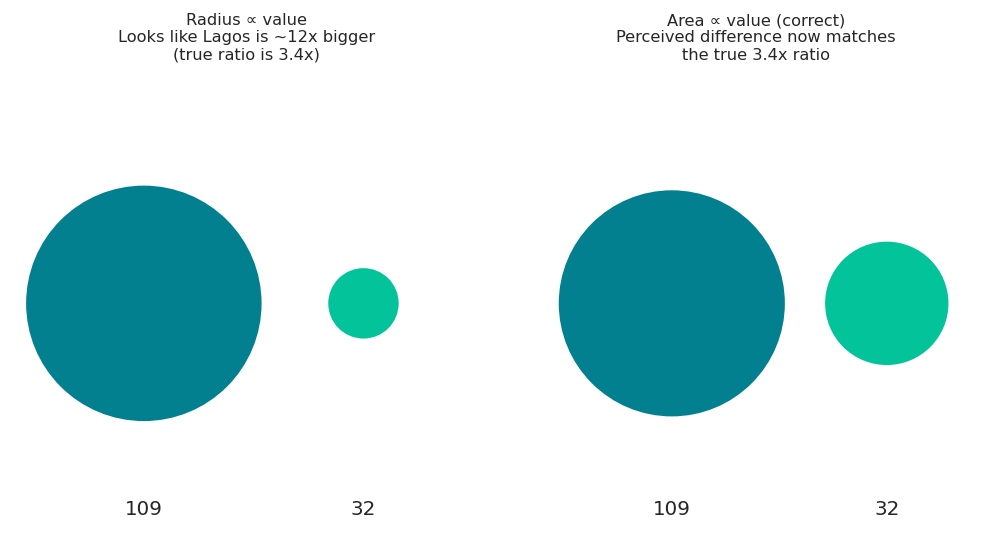

In [26]:
import matplotlib.patches as mpatches
import numpy as np
lagos_n, kano_n = 109, 32   # true ratio: 3.4x

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))

# WRONG: radius scaled linearly with value
ax = axes[0]
r_scale = 0.25 / lagos_n   # largest circle gets radius 0.25
circ_lagos = mpatches.Circle((0.28, 0.5), lagos_n * r_scale, color=GOOD)
circ_kano = mpatches.Circle((0.75, 0.5), kano_n * r_scale, color=ACCENT)
ax.add_patch(circ_lagos); ax.add_patch(circ_kano)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Radius ∝ value\nLooks like Lagos is ~{(lagos_n/kano_n)**2:.0f}x bigger\n(true ratio is {lagos_n/kano_n:.1f}x)', fontsize=9)
ax.text(0.28, 0.05, f'{lagos_n}', ha='center'); ax.text(0.75, 0.05, f'{kano_n}', ha='center')

# CORRECT: area scaled with value (radius proportional to sqrt(value))
ax = axes[1]
area_scale = 0.24 / np.sqrt(lagos_n)   # largest circle gets radius 0.24
circ_lagos2 = mpatches.Circle((0.32, 0.5), np.sqrt(lagos_n) * area_scale, color=GOOD)
circ_kano2 = mpatches.Circle((0.78, 0.5), np.sqrt(kano_n) * area_scale, color=ACCENT)
ax.add_patch(circ_lagos2); ax.add_patch(circ_kano2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Area ∝ value (correct)\nPerceived difference now matches\nthe true {lagos_n/kano_n:.1f}x ratio', fontsize=9)
ax.text(0.32, 0.05, f'{lagos_n}', ha='center'); ax.text(0.78, 0.05, f'{kano_n}', ha='center')

plt.tight_layout()
plt.show()


### 13.4 Excessive colours

**What is wrong:** every bar/slice gets its own colour from a rainbow palette, even though
colour encodes no additional variable.
**Why it misleads:** it isn't strictly "misleading" about a number, but it actively harms
reading speed — the eye tries to find meaning in the colour choices where none exists, and
important comparisons get lost in the noise.
**How to fix it:** one colour for the data, a second accent colour reserved for the single most
important value.

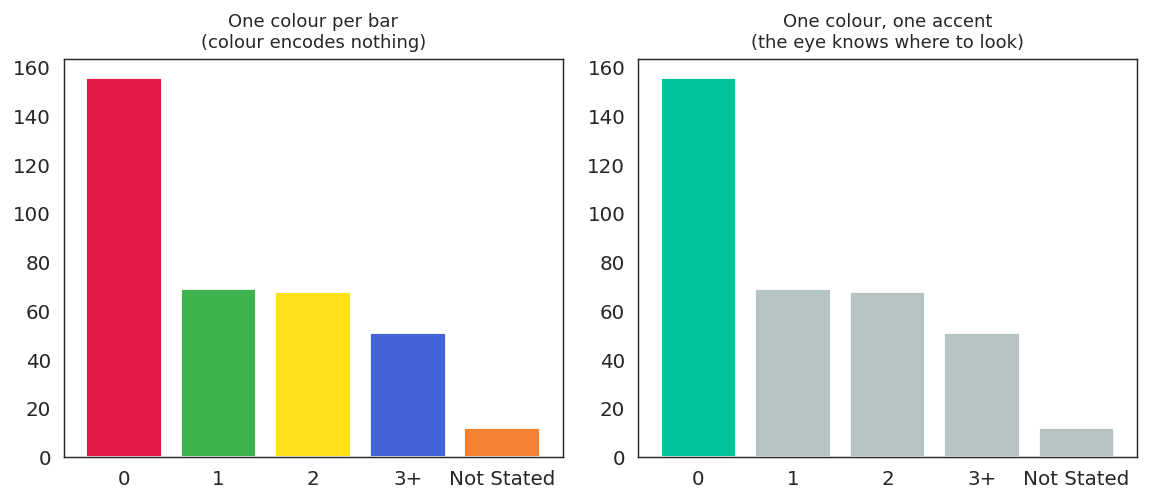

In [27]:
dep_counts = df['Dependents'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].bar(dep_counts.index.astype(str), dep_counts.values, color=BAD_RAINBOW[:len(dep_counts)])
axes[0].set_title('One colour per bar\n(colour encodes nothing)', fontsize=10)

axes[1].bar(dep_counts.index.astype(str), dep_counts.values,
            color=[ACCENT if v == dep_counts.max() else MUTED for v in dep_counts])
axes[1].set_title('One colour, one accent\n(the eye knows where to look)', fontsize=10)
plt.tight_layout()
plt.show()


### 13.5 Dual-axis confusion

**What is wrong:** two variables with unrelated units and scales are plotted on the same chart
with two separate y-axes.
**Why it misleads:** the visual overlap between the two lines depends entirely on where each
axis happens to start and how it's scaled — both arbitrary choices. Nudge either axis and you
can make the lines cross, converge, or diverge at will, without the underlying data changing at
all.
**How to fix it:** use two separate small charts stacked vertically, sharing the x-axis — the
reader can still compare timing, without a fabricated visual relationship.

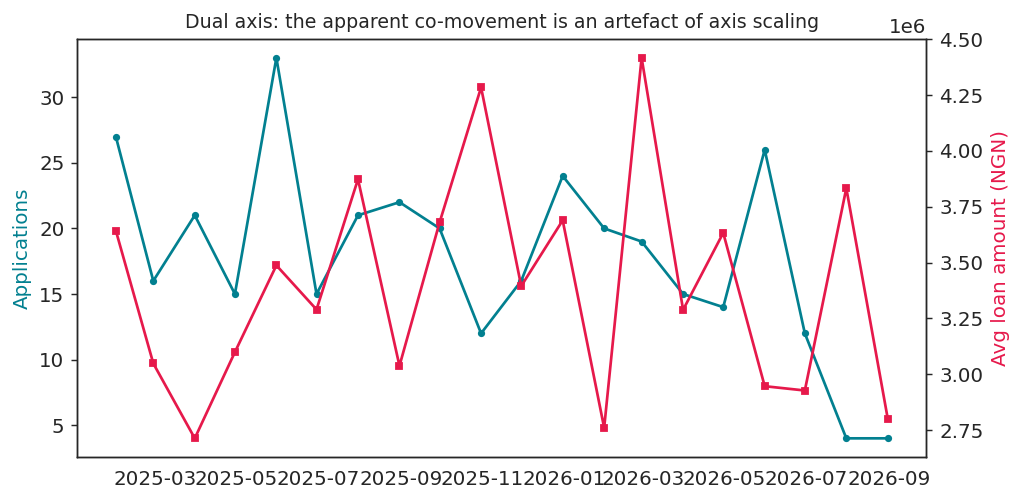

In [28]:
monthly = df.set_index('Application_Date').resample('ME').agg(
    apps=('Application_ID', 'count'), avg_loan=('Loan_Amount_NGN', 'mean'))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(monthly.index, monthly['apps'], color=GOOD, marker='o', markersize=3)
ax1.set_ylabel('Applications', color=GOOD)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['avg_loan'], color=BAD_RAINBOW[0], marker='s', markersize=3)
ax2.set_ylabel('Avg loan amount (NGN)', color=BAD_RAINBOW[0])
ax1.set_title('Dual axis: the apparent co-movement is an artefact of axis scaling', fontsize=10.5)
plt.tight_layout()
plt.show()


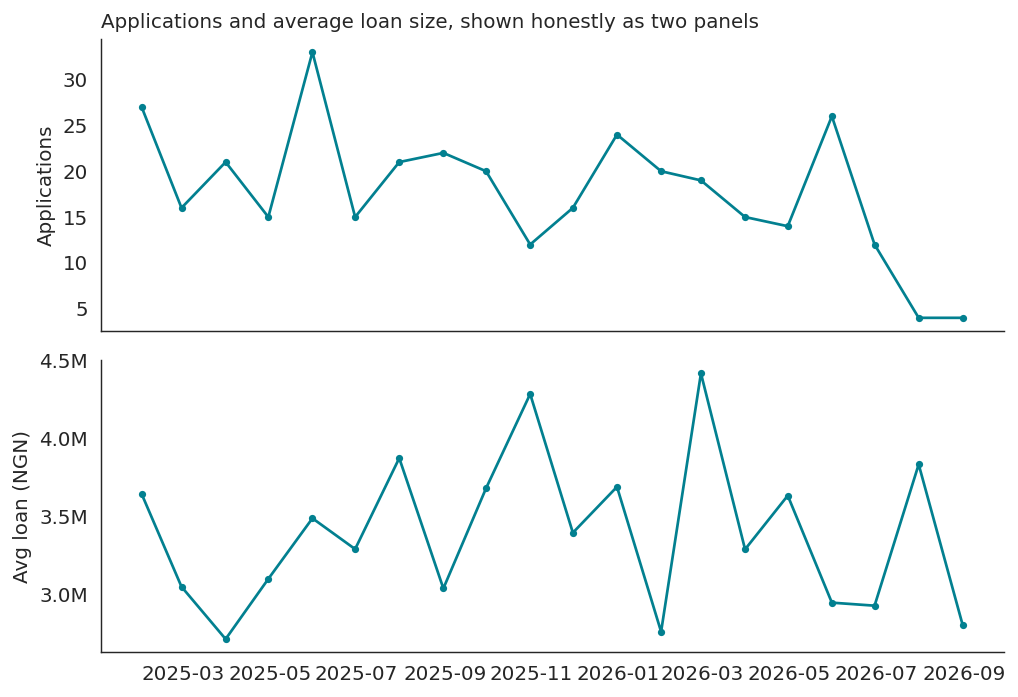

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)
ax1.plot(monthly.index, monthly['apps'], color=GOOD, marker='o', markersize=3)
ax1.set_ylabel('Applications')
ax1.set_title('Applications and average loan size, shown honestly as two panels', fontsize=11, loc='left')
ax2.plot(monthly.index, monthly['avg_loan'], color=GOOD, marker='o', markersize=3)
ax2.set_ylabel('Avg loan (NGN)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
sns.despine()
plt.tight_layout()
plt.show()


Notice the two-panel version makes it easy to see that **volume and average loan size don't
actually move together** — a relationship the dual-axis version visually implied just by how the
two arbitrary scales happened to line up.

### 13.6 Inappropriate pie charts

**What is wrong:** too many slices, or slices too close in size to compare by angle.
**Why it misleads:** the human eye is genuinely bad at comparing angles and areas precisely —
past 4-5 slices, or with several similarly-sized slices, a pie chart stops communicating
anything a bar chart wouldn't show faster and more accurately.
**How to fix it:** use a sorted bar chart once you're past about 4 categories (as in Sections 5
and 9).

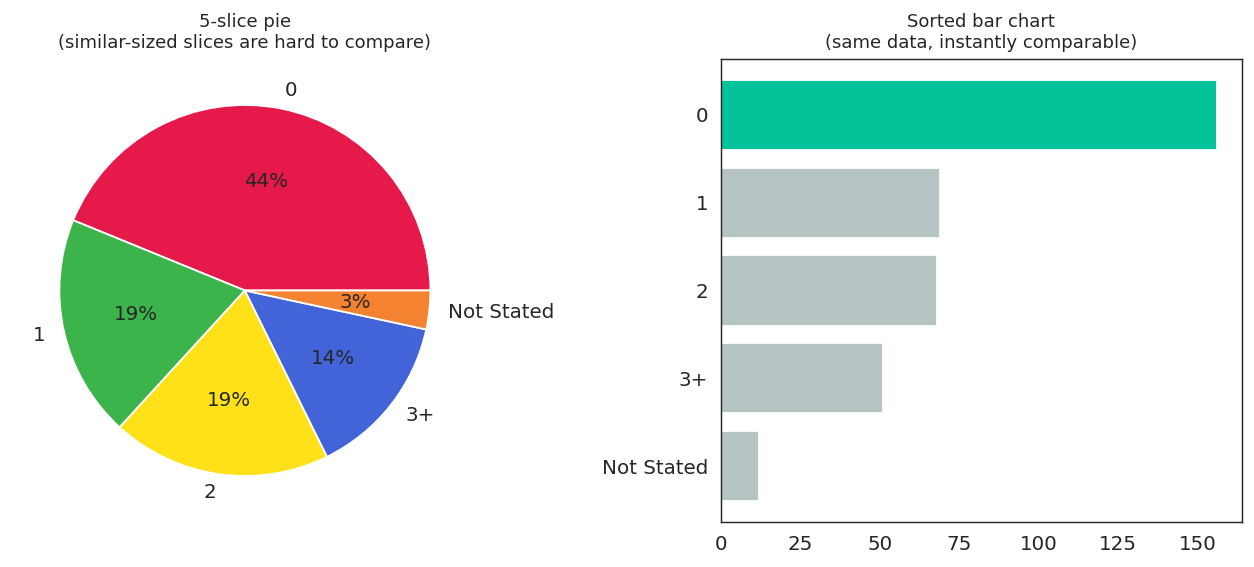

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].pie(dep_counts, labels=dep_counts.index.astype(str), autopct='%1.0f%%', colors=BAD_RAINBOW)
axes[0].set_title(f'{len(dep_counts)}-slice pie\n(similar-sized slices are hard to compare)', fontsize=10)

order = dep_counts.sort_values()
axes[1].barh(order.index.astype(str), order.values, color=[ACCENT if v==order.max() else MUTED for v in order])
axes[1].set_title('Sorted bar chart\n(same data, instantly comparable)', fontsize=10)
plt.tight_layout()
plt.show()


### 13.7 Overloaded charts

**What is wrong:** too many variables, series, and annotations crammed onto one chart.
**Why it misleads:** it doesn't distort any single number, but it prevents the reader from
finding *any* number — which has the same practical effect as hiding it.
**How to fix it:** one chart, one question. Split an overloaded chart into small multiples, or
cut every series that doesn't serve the one question you started with (Section 3).

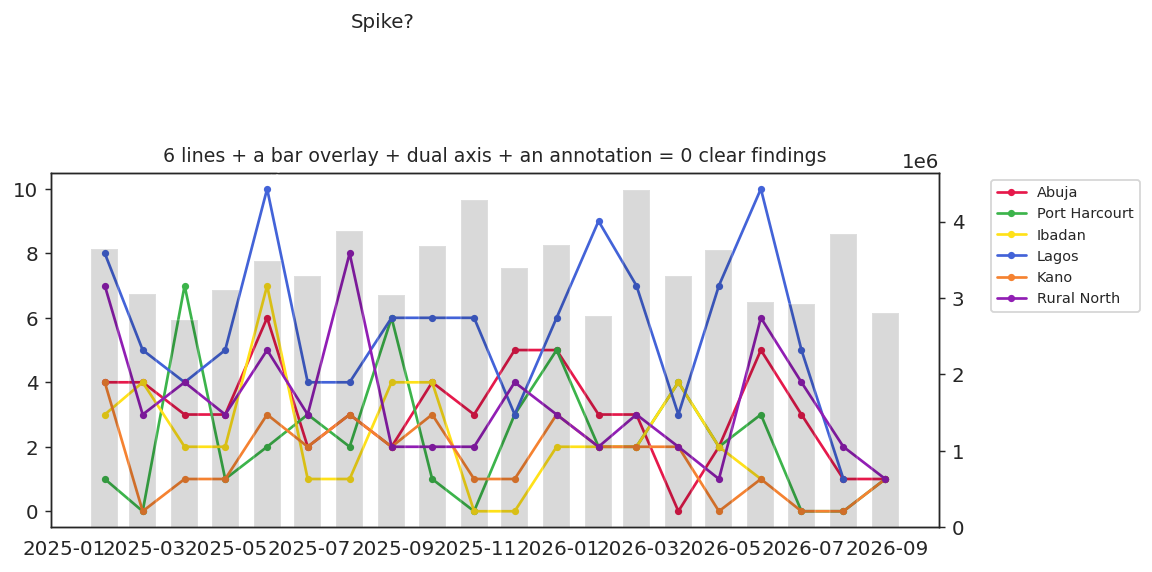

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
for i, region in enumerate(df['Branch_Region'].unique()):
    sub = df[df['Branch_Region'] == region].set_index('Application_Date').resample('ME').size()
    ax.plot(sub.index, sub.values, color=BAD_RAINBOW[i], label=region, marker='o', markersize=3)
ax2 = ax.twinx()
overall_avg = df.set_index('Application_Date').resample('ME')['Loan_Amount_NGN'].mean()
ax2.bar(overall_avg.index, overall_avg.values, alpha=0.15, color='black', width=20)
ax.annotate('Spike?', xy=(pd.Timestamp('2025-05-31'), 10), xytext=(pd.Timestamp('2025-08-01'), 15),
            arrowprops=dict(arrowstyle='->'))
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8)
ax.set_title('6 lines + a bar overlay + dual axis + an annotation = 0 clear findings', fontsize=10.5)
plt.tight_layout()
plt.show()


There is no "good" rebuild for this one shown here on purpose — the fix **is** Sections 6 and
7's already-built clean single-line trend and sorted bar chart. An overloaded chart's cure is
almost always deletion, not redesign.

### 13.8 Misleading aggregation

**What is wrong:** reporting an average or rate without disclosing the sample size behind it.
**Why it misleads:** Kano's 50% approval rate (Section 1) looks like a solid, alarming finding —
but it's calculated from only 32 applications. A rate from a small sample can swing widely by
chance alone.
**How to fix it:** show the sample size next to any rate or average, and where it matters,
show the uncertainty around it.

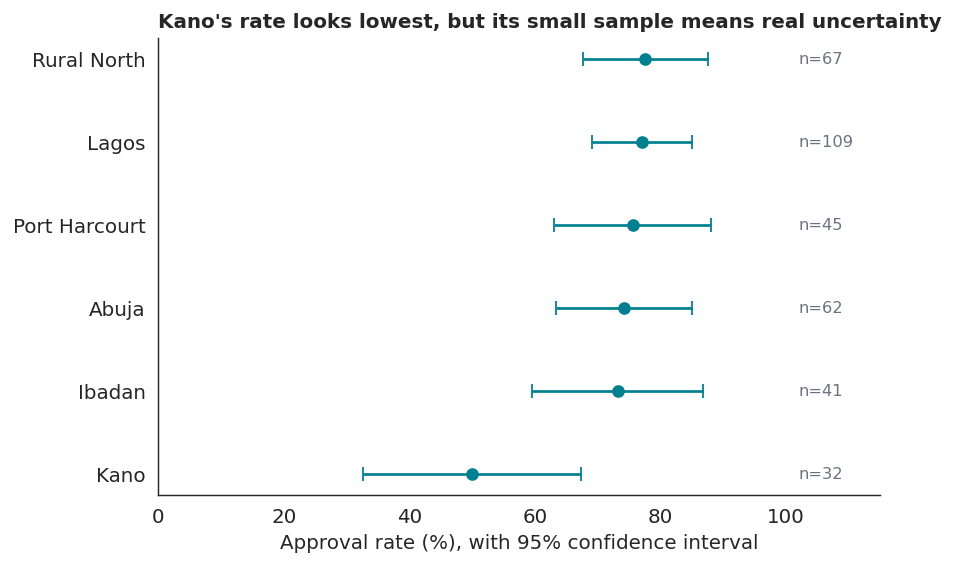

In [32]:
import numpy as np

branch_stats = df.groupby('Branch_Region').agg(
    n=('Application_ID', 'count'),
    rate=('Loan_Status', lambda s: (s == 'Approved').mean())
)
branch_stats['se'] = np.sqrt(branch_stats['rate'] * (1 - branch_stats['rate']) / branch_stats['n'])
branch_stats['ci_low'] = (branch_stats['rate'] - 1.96 * branch_stats['se']).clip(0, 1)
branch_stats['ci_high'] = (branch_stats['rate'] + 1.96 * branch_stats['se']).clip(0, 1)
branch_stats = branch_stats.sort_values('rate')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(branch_stats['rate'] * 100, branch_stats.index,
            xerr=[(branch_stats['rate'] - branch_stats['ci_low']) * 100,
                  (branch_stats['ci_high'] - branch_stats['rate']) * 100],
            fmt='o', color=GOOD, capsize=4)
for y, (region, row) in enumerate(branch_stats.iterrows()):
    ax.text(102, y, f'n={row.n:.0f}', va='center', fontsize=9, color='#6B7280')
ax.set_xlim(0, 115)
ax.set_xlabel('Approval rate (%), with 95% confidence interval')
ax.set_title('Kano\'s rate looks lowest, but its small sample means real uncertainty',
             fontsize=11, fontweight='bold', loc='left')
sns.despine()
plt.tight_layout()
plt.show()


Kano's confidence interval (roughly 33-67%) is far wider than any other branch's — the honest
conclusion is "Kano's approval rate might genuinely be low, but we don't have enough applications
yet to be as confident as the headline number implies," not "Kano is broken."

### 13.9 Cherry-picked time periods

**What is wrong:** choosing a short window of time that shows the desired story, while ignoring
the full history.
**Why it misleads:** every real time series has some short window that goes up and some that
goes down. Presenting only the convenient window implies a trend that the full picture doesn't
support.
**How to fix it:** always show the full available history by default. If you must zoom into a
period, show it alongside the full series, not instead of it.

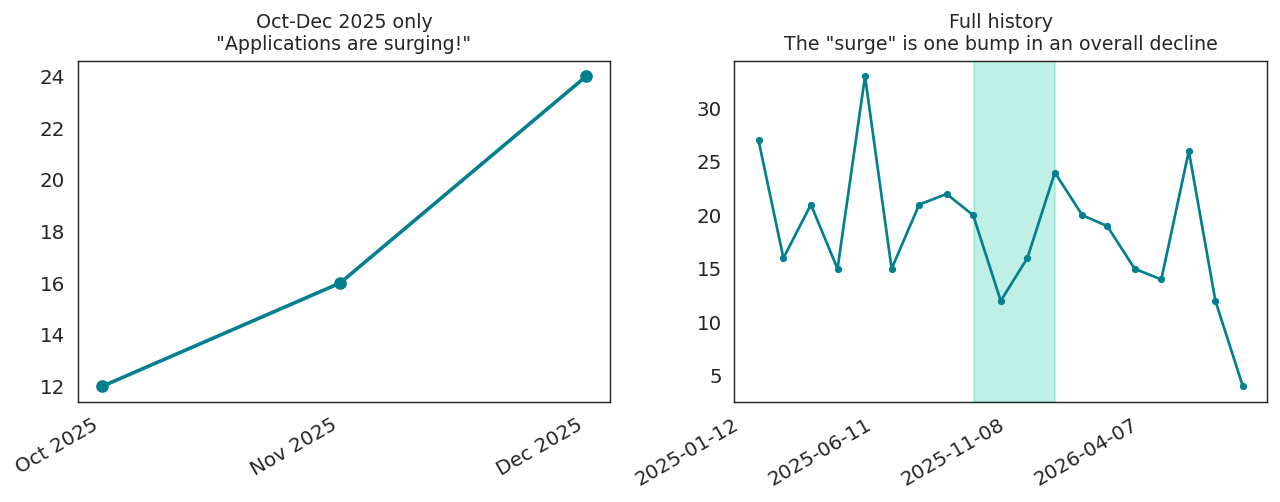

In [33]:
window = monthly_total.loc['2025-10-31':'2025-12-31']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(window.index, window.values, color=GOOD, marker='o', linewidth=2)
axes[0].set_title('Oct-Dec 2025 only\n"Applications are surging!"', fontsize=10.5)
axes[0].set_xticks(window.index)
axes[0].set_xticklabels([d.strftime('%b %Y') for d in window.index])

axes[1].plot(monthly_total.index, monthly_total.values, color=GOOD, marker='o', markersize=3)
axes[1].axvspan(pd.Timestamp('2025-10-01'), pd.Timestamp('2025-12-31'), color=ACCENT, alpha=0.25)
axes[1].set_title('Full history\nThe "surge" is one bump in an overall decline', fontsize=10.5)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(6))
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


### 13.10 Missing context

**What is wrong:** a headline number is reported with no baseline, no sample size, and no
comparison to help the reader judge whether it's actually meaningful.
**Why it misleads:** "approval rate rose 5 points" sounds significant on its own. It sounds very
different once you know it's a rise from a small base, during a month when the branch also
processed a third as many applications as usual.
**How to fix it:** pair every headline statistic with the context needed to judge it: the
sample size, the comparison baseline, and any known confound.

**Bad:** *"Kano's approval rate improved to 56% last month — up 6 points!"*

**With context:** *"Kano's approval rate was 56% last month, up from 50% year-to-date — but on
only 9 applications that month (vs. Kano's usual ~3-4 per month over a quiet period), so this
single month shouldn't be read as a policy change taking effect yet."*

**The rule:** *if a stated finding would change your recommendation, it earns a sentence of
context. A chart or number without that context isn't necessarily lying — but it's asking the
reader to trust a conclusion they don't have enough information to check.*

---
## Which chart would you choose?

Work through these five using the framework from Section 4 before checking the suggested
answer. There's often more than one defensible choice — the point is justifying it.

1. *"Compare average income between married and single applicants."*
2. *"Show how the mix of Salaried vs Self-Employed applicants has changed month by month."*
3. *"Is there a relationship between loan term length and loan amount?"*
4. *"What's the exact approval rate, application count, and average loan size for each branch,
   for a board pack appendix?"*
5. *"Show the full distribution of loan-to-income ratios, and flag anything unusually high."*

<details><summary><b>Suggested answers (click to expand in Jupyter, or scroll past in a
static viewer)</b></summary>

1. **Bar chart** — two categories, one numeric comparison (Section 5).
2. **Stacked bar chart** or small-multiple line charts — composition changing over time. A
   single stacked area/bar chart per month is the standard choice here.
3. **Scatter plot** — two numeric variables, looking for a relationship (Section 8).
4. **Table** — precise, mixed-scale figures for quoting, not a pattern to spot (Section 12).
5. **Histogram or box plot** — distribution shape and outliers (Section 7).

</details>

---
## Practical activity — five business questions

For each question: **(a)** name the chart type you'd choose, **(b)** justify it using the
QUESTION → DATA TYPE → COMPARISON → CHART framework, **(c)** build it below.

1. Does education level relate to loan approval?
2. How has the mix of loan purposes shifted across the branches?
3. Which branch has the most volatile month-to-month application volume?
4. Do married applicants request larger loans than single applicants, and is the difference
   meaningful given the sample sizes?
5. Build the one chart you'd put on the first slide of a briefing to AJEBO's board — and justify
   why it's that one.

**Space to build your answers:**

In [34]:
# Q1 - your chart here



In [35]:
# Q2 - your chart here



In [36]:
# Q3 - your chart here



In [37]:
# Q4 - your chart here



In [38]:
# Q5 - your chart here



**One worked answer, for Q1 (education vs. approval), so you can check your approach:**

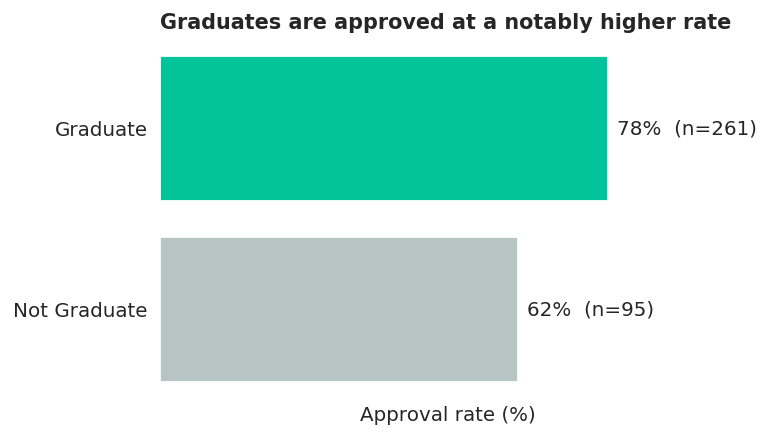

In [39]:
edu_appr = (df.groupby('Education')['Loan_Status']
              .apply(lambda s: (s == 'Approved').mean()) * 100).sort_values()
n_by_edu = df['Education'].value_counts()

fig, ax = plt.subplots(figsize=(6, 3.5))
colors = [ACCENT if v == edu_appr.max() else MUTED for v in edu_appr]
bars = ax.barh(edu_appr.index, edu_appr.values, color=colors)
ax.set_xlim(0, 100)
ax.set_title('Graduates are approved at a notably higher rate', fontsize=11.5, fontweight='bold', loc='left')
ax.set_xlabel('Approval rate (%)')
for bar, (edu, val) in zip(bars, edu_appr.items()):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%  (n={n_by_edu[edu]})', va='center')
sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.tight_layout()
plt.show()


Notice the sample sizes are included directly on the chart (261 vs 95) — a direct callback to
Section 13.8. A 16-point gap on a sample of 95 is real signal, not noise, but it's still worth
naming the sample size rather than letting the reader assume it.

---
## Final challenge — critique and rebuild

Here is a chart a (fictional) junior analyst submitted for a branch performance review. Find
every problem, then rebuild it.

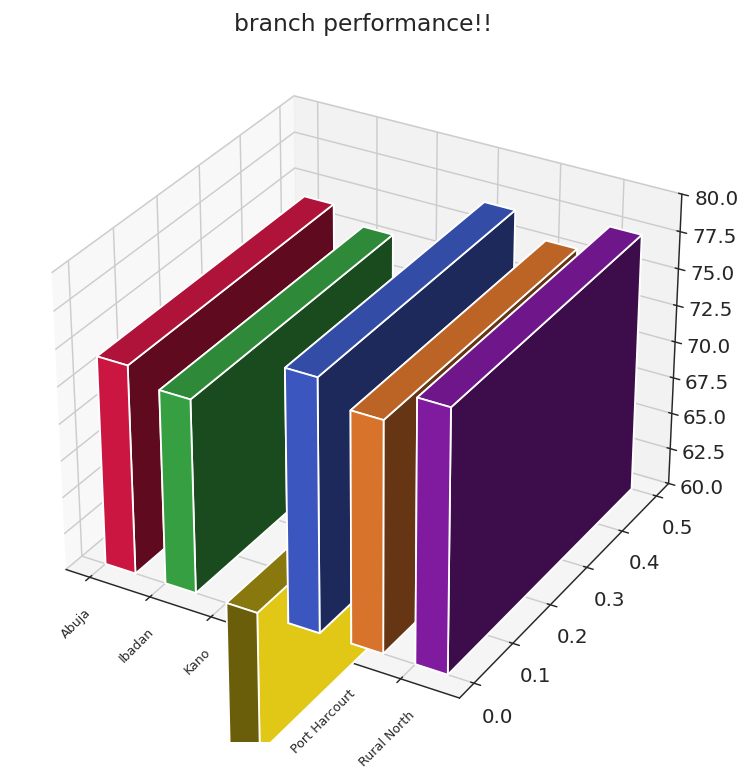

In [40]:
branch_data = df.groupby('Branch_Region').agg(
    Applications=('Application_ID', 'count'),
    Approval_Rate=('Loan_Status', lambda s: (s == 'Approved').mean() * 100)
)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
xs = range(len(branch_data))
ax.bar3d(xs, [0]*len(xs), [60]*len(xs), 0.5, 0.5,
         branch_data['Approval_Rate'].values - 60, color=BAD_RAINBOW[:6])
ax.set_zlim(60, 80)
ax.set_xticks(xs)
ax.set_xticklabels(branch_data.index, rotation=45, fontsize=7)
ax.set_title('branch performance!!', fontsize=13)
plt.tight_layout()
plt.show()


**Your turn — list every problem you can find, then rebuild it below** (a full list of
violations follows afterward, so try before you look).

In [41]:
# Your rebuild here




<details><summary><b>Problems in the original (click to expand)</b></summary>

1. 3D bars with a truncated, offset z-axis (starts at 60, and the bar heights are drawn as
   *value minus 60* — actively fabricating the baseline).
2. A meaningless, unprofessional title ("branch performance!!") with no finding stated.
3. Six arbitrary rainbow colours encoding nothing.
4. Not sorted by value — no ranking is visible at a glance.
5. No axis label stating these are percentages.
6. Tiny, rotated category labels.

</details>

**One possible rebuild:**

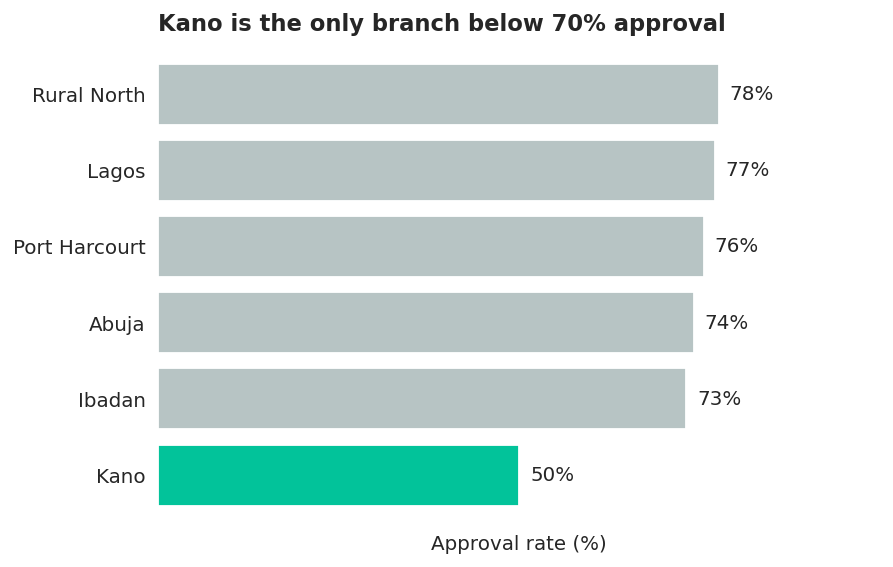

In [42]:
order = branch_data['Approval_Rate'].sort_values()
colors = [ACCENT if v == order.min() else MUTED for v in order]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(order.index, order.values, color=colors)
ax.set_xlim(0, 100)
ax.set_xlabel('Approval rate (%)')
ax.set_title('Kano is the only branch below 70% approval', fontsize=12.5, fontweight='bold', loc='left')
for bar, val in zip(bars, order.values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center')
sns.despine(left=True, bottom=True)
ax.set_xticks([])
plt.tight_layout()
plt.show()


---
## Visualisation checklist

Run every chart through this before sharing it:

- [ ] Does the title state a finding, not just a column name?
- [ ] Does the y-axis (or relevant numeric axis) start at zero, or is the exception disclosed?
- [ ] Are both axes labelled, with units?
- [ ] Is the chart type actually the narrowest fit for the question (Section 4)?
- [ ] Are categories sorted by value, when the question is about ranking or comparison?
- [ ] Does colour encode something real, or is it decoration?
- [ ] Is there a legend only when there's more than one series, placed clearly?
- [ ] Are sample sizes shown wherever a rate or average could be misread as more certain than it is?
- [ ] Has every gridline, 3D effect, and drop-shadow that adds no information been removed?
- [ ] Would a colour-blind reader, or a black-and-white printout, still understand it?
- [ ] If a table would answer the question faster or more precisely, have you used a table?

---
## Knowledge check — 5 questions

1. Why is a pie chart the wrong choice for comparing two independent averages (Section 5)?
2. What's the difference between a histogram and a bar chart, and when does each apply?
3. Why does starting a y-axis above zero mislead, even if the axis is clearly labelled with its
   actual range?
4. Kano's approval rate is the lowest of all six branches. Name one piece of context that should
   accompany that headline number before anyone acts on it.
5. When is a table a better choice than any chart?

<details><summary><b>Answer key</b></summary>

1. A pie chart shows parts of one whole; two independent averages aren't parts of a whole, so
   the percentages shown are shares of an artificial combined total with no business meaning.
2. A histogram bins a single numeric variable to show its distribution shape; a bar chart
   compares a value across separate named categories. Row order or an ID is not a category.
3. Because the reader's eye judges the *visual* gap between bars, not the printed axis numbers —
   a labelled-but-truncated axis still exaggerates the gap to anyone reading at a glance.
4. Kano's sample size (32 applications) and the resulting wide confidence interval (Section
   13.8) — the true rate could plausibly be meaningfully higher.
5. When the actual need is precise lookup or quoting of exact, often mixed-scale figures, rather
   than spotting a pattern (Section 12).

</details>

---
## Common mistakes

- **Charting a column instead of a question.** Always state the question in words first
  (Section 3).
- **Defaulting to a bar chart or a pie chart out of habit**, without checking the framework.
- **Sorting alphabetically instead of by value** when the question is about ranking.
- **Trusting the default axis range** matplotlib or Excel picks, without checking whether it
  starts at zero.
- **Reporting a rate or average with no sample size**, especially for small or uneven groups.
- **Adding 3D, shadows, or gradient fills** because they look more polished — they almost always
  make the chart harder to read accurately.
- **Cramming every available variable into one chart** instead of asking which ones actually
  serve the stated question.

---
## Next: Module 6.3 — Insight Narrative and Business Communication

> *A good chart communicates a finding; a good narrative explains why the finding matters.*

Every chart in this notebook answers a "what" — Kano's approval rate is lower, income is
right-skewed, income and loan size move together. None of them yet says *so what should AJEBO
do about it*. That's Module 6.3: turning a correct, honest chart into a recommendation someone
can act on.